# 23CSE301 Machine Learning — Capstone Project
## Classification Track — Review 1, Part A

**Team:** TASKMASTERS (Team 16)  
**Dataset:** Australian Open Tennis Matches (2008–2022)  
**Target:** `higher_rank_won`

---

### Project objective

This notebook builds classification models to predict whether the higher-ranked player won an Australian Open men's singles match. The modelling features are constructed from player-to-player differences so that the representation is symmetric with respect to the match participants.

### Review 1 scope

| Component | Coverage |
|---|---|
| Exploratory data analysis | Dataset audit, feature distributions, class distribution, correlation and feature-target relationships |
| Data preparation | Missing-value handling, outlier assessment and target preparation |
| Feature engineering | Rank, experience, height and weight gaps; handedness encoding |
| Classification models | 5 algorithms required for Part A |
| Evaluation | Accuracy, Precision, Recall, weighted F1, ROC-AUC and confusion matrices |
| Model comparison | Common held-out test set and separate comparison visualisation |
| Validation | 5-fold cross-validation for the two strongest models |

### Notebook structure

**EDA → Leakage-aware feature engineering → Stratified split → Preprocessing → Five classifiers → Evaluation → ROC/confusion analysis → Cross-validation → Review 1 summary**


### Classification model reference

| # | Algorithm | Core idea |
|---:|---|---|
| 1 | **Logistic Regression** | Estimates class probability through a sigmoid-based linear model. |
| 2 | **K-Nearest Neighbors** | Classifies an observation from the labels of nearby training observations. |
| 3 | **Gaussian Naive Bayes** | Uses Bayes' theorem with a conditional-independence assumption and Gaussian feature distributions. |
| 4 | **Decision Tree Classifier** | Learns hierarchical if/then-style splits using an impurity criterion. |
| 5 | **Support Vector Machine (SVC)** | Finds a decision boundary with a maximum-margin objective; kernels enable non-linear boundaries. |

**Evaluation measures:** Accuracy, weighted Precision, weighted Recall, weighted F1, ROC-AUC and confusion matrix.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")

DATA_URL = "https://data.scorenetwork.org/data/AustralianOpen.csv"
DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_PATH = DATA_DIR / "AustralianOpen.csv"

def load_australian_open():
    if LOCAL_PATH.exists():
        return pd.read_csv(LOCAL_PATH, encoding="latin1")
    data = pd.read_csv(DATA_URL, encoding="latin1")
    data.to_csv(LOCAL_PATH, index=False)
    return data

df = load_australian_open()

print("Shape:", df.shape)
display(df.head())


Shape: (1905, 19)


,Year,Winner,Loser,WRank,LRank,pl1_flag,pl1_year_pro,pl1_weight,pl1_height,pl1_hand,pl2_flag,pl2_year_pro,pl2_weight,pl2_height,pl2_hand,higher_rank_won,rank_diff,rank_diff_cat,same_handedness
0,2022,Shapovalov D.,Djere L.,14,51.0,CAN,2016,76,183,Left,SRB,2013.0,80.0,185.0,Right,Yes,-37.0,Medium,No
1,2022,Kwon S.W.,Rune H.,54,99.0,KOR,2015,72,180,Right,DEN,2020.0,77.0,188.0,Right,Yes,-45.0,Medium,Yes
2,2022,Lajovic D.,Fucsovics M.,39,35.0,SRB,2007,78,183,Right,HUN,2010.0,82.0,188.0,Right,No,4.0,Low,Yes
3,2022,Vukic A.,Harris L.,144,33.0,AUS,2018,85,188,Right,RSA,2015.0,80.0,193.0,Right,No,111.0,High,Yes
4,2022,Garin C.,Bagnis F.,19,72.0,CHI,2013,85,185,Right,ARG,2008.0,82.0,183.0,Left,Yes,-53.0,Medium,No


## Section A — Dataset & EDA

### A1. Dataset loading and audit

In [2]:
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget counts:")
display(df["higher_rank_won"].value_counts(dropna=False).to_frame("count"))


Number of rows: 1905
Number of columns: 19

Data types:


,dtype
Year,int64
Winner,str
Loser,str
WRank,int64
LRank,float64
pl1_flag,str
pl1_year_pro,int64
pl1_weight,int64
pl1_height,int64
pl1_hand,str



Missing values:


,missing_count
pl2_weight,29
pl2_height,29
pl2_flag,29
pl2_hand,29
pl2_year_pro,29
same_handedness,29
higher_rank_won,6
rank_diff,6
rank_diff_cat,6
LRank,6



Duplicate rows: 0

Target counts:


,count
higher_rank_won,
Yes,1413
No,486
NaN,6


**Dataset context.** The audit establishes the number of match records, variable types, missingness and duplicate rows. The SCORE dataset contains 1,905 men's Australian Open matches from 2008–2022, providing the basis for the binary prediction task.

### A2. EDA visualisations

The dataset has a mixture of player characteristics and match information. For Review 1, I focus the plots on variables that can later be turned into symmetric differences between the two players.

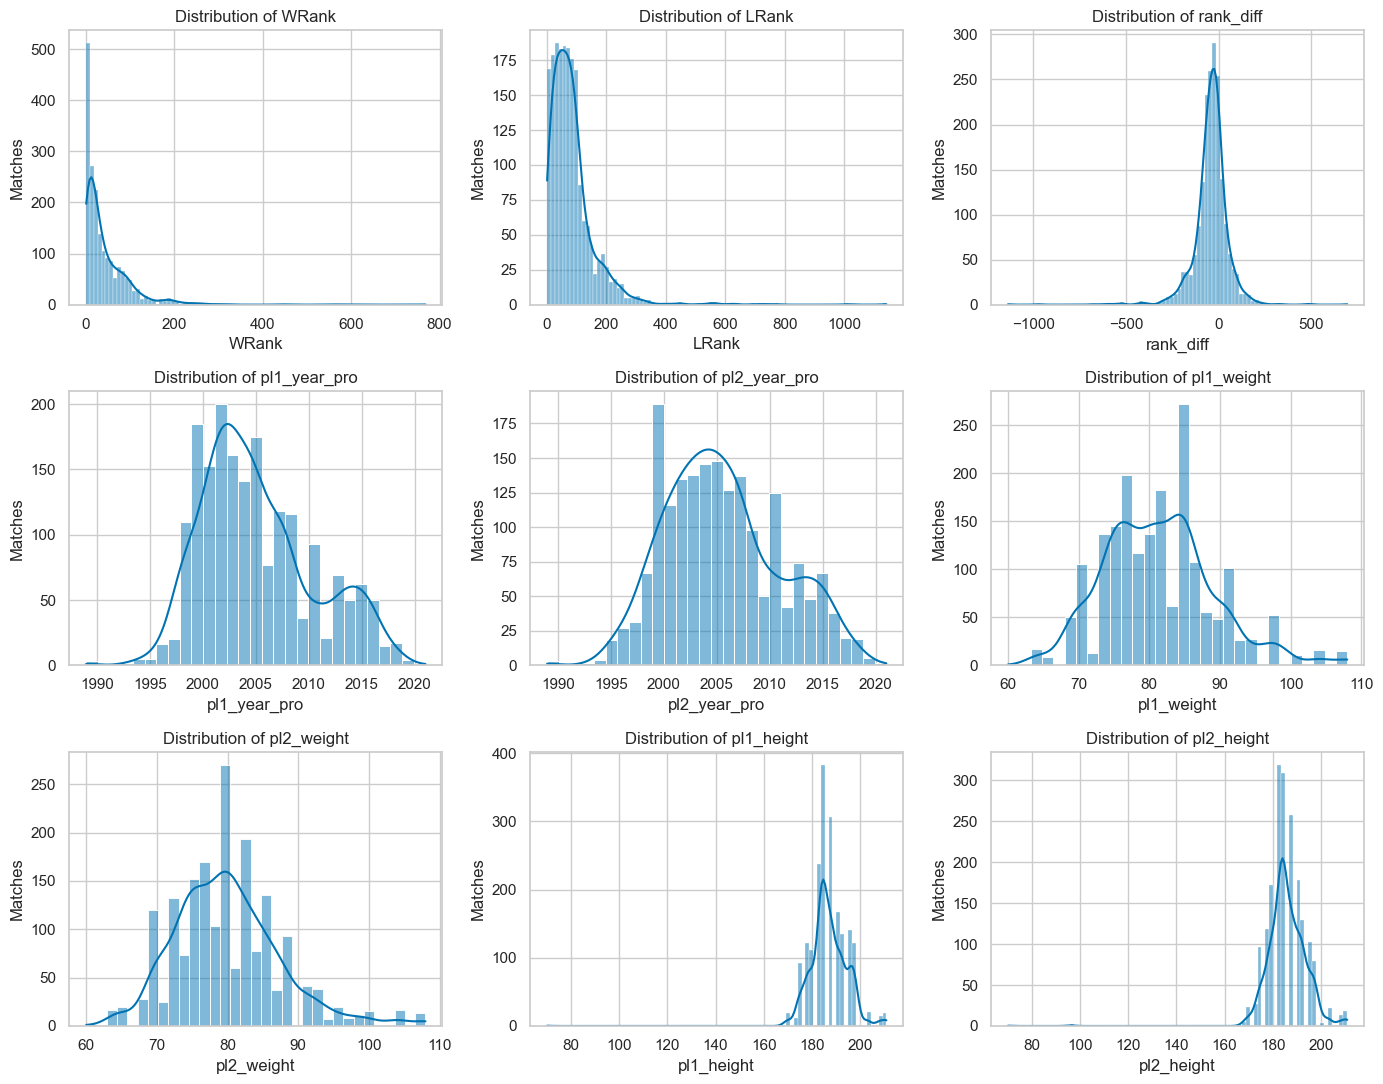

In [3]:
eda_features = [
    "WRank", "LRank", "rank_diff",
    "pl1_year_pro", "pl2_year_pro",
    "pl1_weight", "pl2_weight",
    "pl1_height", "pl2_height"
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))

for ax, column in zip(axes.ravel(), eda_features):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Matches")

plt.tight_layout()
plt.show()


**Feature distribution analysis.** The distributions reveal differences in scale, concentration and tail behaviour across ranking, physical and player-experience variables. This information supports the later use of imputation and standardisation inside the modelling pipeline.

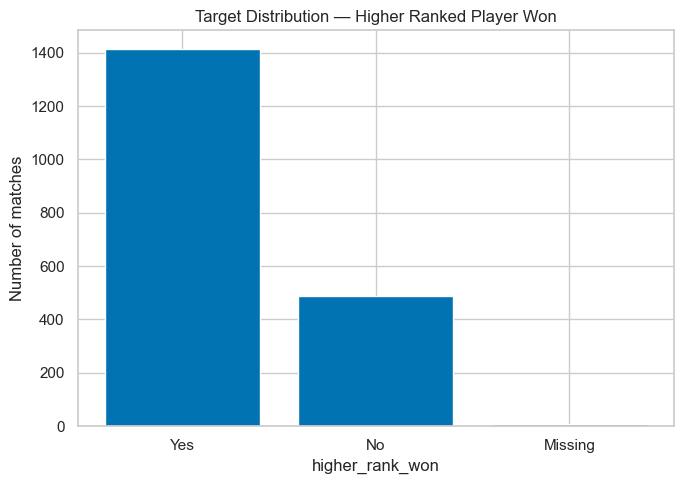

In [4]:
target_counts = (
    df["higher_rank_won"]
    .astype("string")
    .fillna("Missing")
    .value_counts()
)

plt.figure(figsize=(7, 5))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Target Distribution — Higher Ranked Player Won")
plt.xlabel("higher_rank_won")
plt.ylabel("Number of matches")
plt.tight_layout()
plt.show()


**Class distribution.** The target distribution shows the relative frequency of the two match-outcome classes. A stratified train/test split preserves this class proportion across the training and held-out test sets.

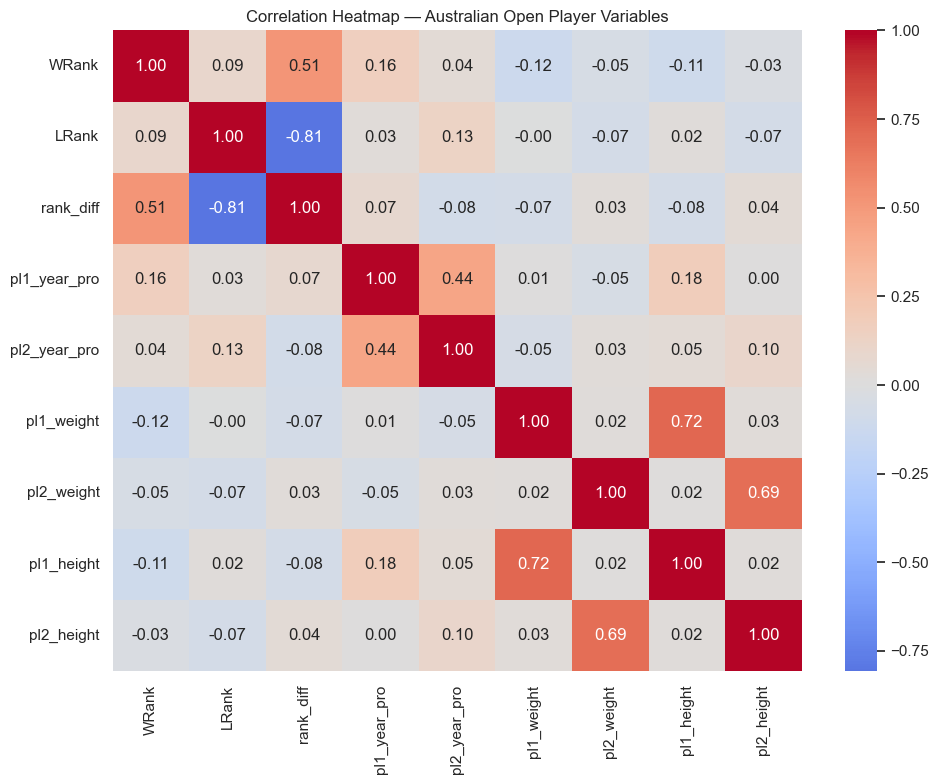

In [5]:
corr_cols = [
    "WRank", "LRank", "rank_diff",
    "pl1_year_pro", "pl2_year_pro",
    "pl1_weight", "pl2_weight",
    "pl1_height", "pl2_height"
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[corr_cols].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap — Australian Open Player Variables")
plt.tight_layout()
plt.show()


**Correlation analysis.** The heatmap shows relationships among the original ranking and player attributes. The strong relationship between winner/loser rankings and `rank_diff` is also a reminder that the original columns encode match outcome direction.

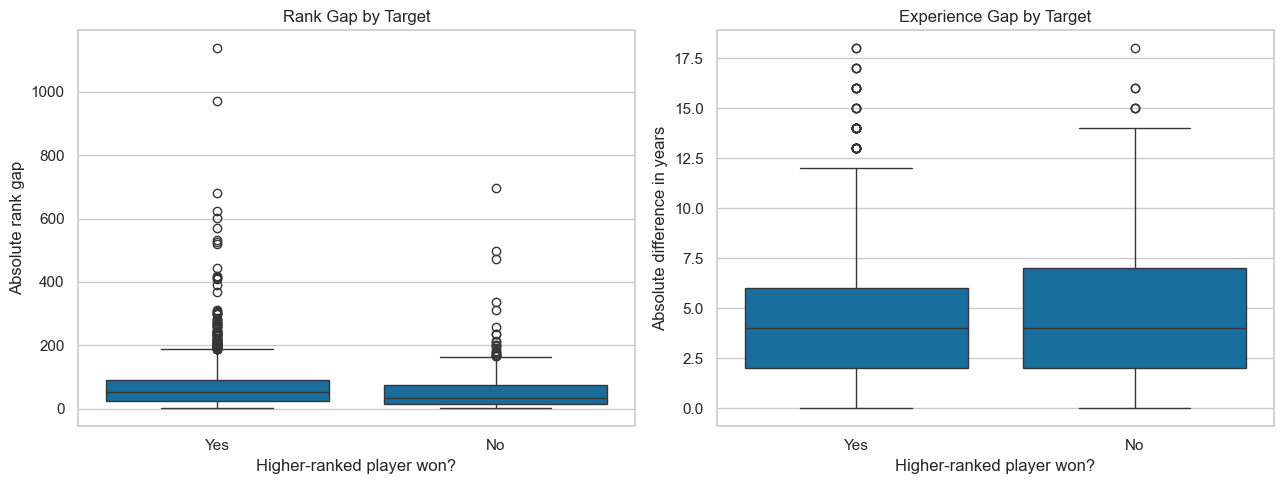

In [6]:
plot_df = df.copy()

# Symmetric features are created for EDA as well.
plot_df["rank_gap_abs"] = (plot_df["WRank"] - plot_df["LRank"]).abs()
plot_df["experience_gap_abs"] = (
    plot_df["pl1_year_pro"] - plot_df["pl2_year_pro"]
).abs()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=plot_df,
    x="higher_rank_won",
    y="rank_gap_abs",
    ax=axes[0]
)
axes[0].set_title("Rank Gap by Target")
axes[0].set_xlabel("Higher-ranked player won?")
axes[0].set_ylabel("Absolute rank gap")

sns.boxplot(
    data=plot_df,
    x="higher_rank_won",
    y="experience_gap_abs",
    ax=axes[1]
)
axes[1].set_title("Experience Gap by Target")
axes[1].set_xlabel("Higher-ranked player won?")
axes[1].set_ylabel("Absolute difference in years")

plt.tight_layout()
plt.show()


**Outcome-group comparison.** The rank-gap and experience-gap visualisations show how the engineered difference features are distributed across the two outcome classes. These plots describe observed associations rather than causal effects.

### Feature-target relationship plots

The target variable is binary, so a small vertical jitter is used to make both outcome classes visible while retaining the continuous feature values.


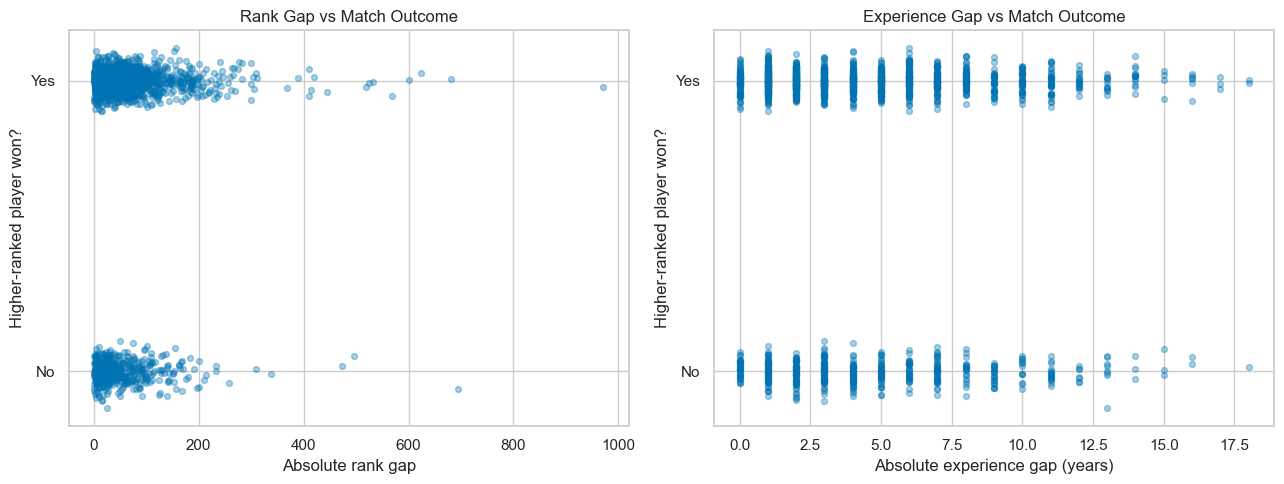

In [7]:
# Feature-target relationship plots
# The binary target is shown with a small vertical jitter so both outcome classes are visible.

scatter_df = plot_df[
    ["rank_gap_abs", "experience_gap_abs", "higher_rank_won"]
].copy()

scatter_df["target_num"] = (
    scatter_df["higher_rank_won"]
    .astype("string")
    .str.strip()
    .str.title()
    .map({"No": 0, "Yes": 1})
)

scatter_df = scatter_df.dropna(
    subset=["rank_gap_abs", "experience_gap_abs", "target_num"]
)

rng = np.random.default_rng(RANDOM_STATE)
scatter_df["target_jitter"] = (
    scatter_df["target_num"]
    + rng.normal(0, 0.035, len(scatter_df))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    scatter_df["rank_gap_abs"],
    scatter_df["target_jitter"],
    alpha=0.35,
    s=18
)
axes[0].set_title("Rank Gap vs Match Outcome")
axes[0].set_xlabel("Absolute rank gap")
axes[0].set_ylabel("Higher-ranked player won?")
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["No", "Yes"])

axes[1].scatter(
    scatter_df["experience_gap_abs"],
    scatter_df["target_jitter"],
    alpha=0.35,
    s=18
)
axes[1].set_title("Experience Gap vs Match Outcome")
axes[1].set_xlabel("Absolute experience gap (years)")
axes[1].set_ylabel("Higher-ranked player won?")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["No", "Yes"])

plt.tight_layout()
plt.show()


**Feature-target relationship.** The jittered scatter plots make the two binary target levels visible while preserving the continuous feature values. They provide a visual complement to the numerical model evaluation that follows.

## Section B — Preprocessing & Feature Engineering

### B1. Data cleaning

There is an important modelling detail in this dataset: `WRank` and `LRank` identify the winner and loser. If we give those two columns directly to a classifier, the model can reconstruct whether the higher-ranked player won from the direction of the ranks. That would make the task misleading.

To avoid this, the modelling data uses **absolute differences** between the two players instead of the original winner/loser-specific columns.

In [8]:
working_df = df.copy()

print("Duplicate rows:", working_df.duplicated().sum())

missing_target = working_df["higher_rank_won"].isna().sum()
print("Missing target rows:", missing_target)

# Potential outlier check for the variables that will be used.
outlier_features = [
    "rank_gap_abs", "experience_gap_abs",
    "height_gap_abs", "weight_gap_abs"
]

# These columns are created below; first prepare the symmetric variables.
working_df["rank_gap_abs"] = (working_df["WRank"] - working_df["LRank"]).abs()
working_df["experience_gap_abs"] = (
    working_df["pl1_year_pro"] - working_df["pl2_year_pro"]
).abs()
working_df["height_gap_abs"] = (
    working_df["pl1_height"] - working_df["pl2_height"]
).abs()
working_df["weight_gap_abs"] = (
    working_df["pl1_weight"] - working_df["pl2_weight"]
).abs()

outlier_summary = []

for column in outlier_features:
    values = working_df[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((values < lower) | (values > upper)).sum()
    outlier_summary.append([column, count])

display(
    pd.DataFrame(outlier_summary, columns=["Feature", "IQR outlier count"])
)


Duplicate rows: 0
Missing target rows: 6


,Feature,IQR outlier count
0,rank_gap_abs,113
1,experience_gap_abs,21
2,height_gap_abs,51
3,weight_gap_abs,55


**Justification:** Potential outliers are checked but not automatically deleted. Large rank gaps or differences in player characteristics can be genuine matches. Missing numerical values will be handled later by a training-only imputer.

### B2. Feature engineering and target preparation

The engineered variables describe the **difference between the two players**, which is more natural for this prediction problem than using winner and loser measurements separately.

In [9]:
working_df["same_handedness_bin"] = (
    working_df["same_handedness"]
    .astype("string")
    .str.strip()
    .str.title()
    .map({"Yes": 1, "No": 0})
)

working_df["target"] = (
    working_df["higher_rank_won"]
    .astype("string")
    .str.strip()
    .str.title()
    .map({"No": 0, "Yes": 1})
)

feature_columns = [
    "rank_gap_abs",
    "experience_gap_abs",
    "height_gap_abs",
    "weight_gap_abs",
    "same_handedness_bin"
]

model_df = working_df[feature_columns + ["target"]].dropna(
    subset=["target"]
).copy()

X = model_df[feature_columns]
y = model_df["target"].astype(int)

print("Modelling rows:", len(model_df))
print("\nTarget distribution:")
display(y.value_counts().sort_index().to_frame("count"))


Modelling rows: 1899

Target distribution:


,count
target,
0,486
1,1413


**Feature engineering note:** `rank_gap_abs` measures how far apart the players are in ranking, while the other gap variables describe differences in experience, height and weight. `same_handedness_bin` keeps the original Yes/No information in a numeric form. These features are easier to explain and avoid using the winner/loser names as predictors.

### B3. Stratified train/test split and preprocessing

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_features = feature_columns

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining class proportions:")
display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .to_frame("proportion")
)


X_train: (1519, 5)
X_test : (380, 5)

Training class proportions:


,proportion
target,
0,0.25609
1,0.74391


The imputer and scaler are inside the pipeline. This is important because the guideline says that preprocessing must be fitted on the training data only. The same fitted transformations are then applied to the test data.

## Section C — Classification Track Part A

The five Part-A models are trained on the same split:

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine

For each model, the notebook records Accuracy, weighted Precision, weighted Recall, weighted F1 and ROC-AUC. A confusion matrix is shown separately for every model.

In [11]:
def classification_metrics(name, model):
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision_weighted": precision_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "Recall_weighted": recall_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "F1_weighted": f1_score(
            y_test, predictions, average="weighted", zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y_test, probabilities)
    }

    return metrics, predictions, probabilities

classification_results = []
classification_predictions = {}
classification_probabilities = {}
classification_models = {}


## 1. Logistic Regression

Logistic Regression is the baseline classifier. It models the probability of the positive class using a sigmoid function. The coefficients show how the predictors change the log-odds when the other variables are held constant.

In [12]:
logistic_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

metrics, pred, prob = classification_metrics(
    "Logistic Regression", logistic_model
)

classification_results.append(metrics)
classification_predictions["Logistic Regression"] = pred
classification_probabilities["Logistic Regression"] = prob
classification_models["Logistic Regression"] = logistic_model

display(pd.DataFrame([metrics]).round(4))


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Logistic Regression,0.7447,0.5546,0.7447,0.6358,0.5935


## 2. K-Nearest Neighbors

KNN classifies a match using the labels of nearby training observations. Because it relies on distances, scaling is important. The value of `k` controls how local the decision is: small `k` is more sensitive to individual observations, while larger `k` produces smoother decisions.

In [13]:
knn_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    knn_model,
    {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__metric": ["euclidean", "manhattan"]
    },
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)
knn_best = knn_grid.best_estimator_

knn_pred = knn_best.predict(X_test)
knn_prob = knn_best.predict_proba(X_test)[:, 1]

knn_metrics = {
    "Model": "K-Nearest Neighbors",
    "Accuracy": accuracy_score(y_test, knn_pred),
    "Precision_weighted": precision_score(y_test, knn_pred, average="weighted", zero_division=0),
    "Recall_weighted": recall_score(y_test, knn_pred, average="weighted", zero_division=0),
    "F1_weighted": f1_score(y_test, knn_pred, average="weighted", zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, knn_prob)
}

classification_results.append(knn_metrics)
classification_predictions["K-Nearest Neighbors"] = knn_pred
classification_probabilities["K-Nearest Neighbors"] = knn_prob
classification_models["K-Nearest Neighbors"] = knn_best

print("Best parameters:", knn_grid.best_params_)
display(pd.DataFrame([knn_metrics]).round(4))


Best parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 3}


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,K-Nearest Neighbors,0.6816,0.6345,0.6816,0.6518,0.5476


## 3. Gaussian Naive Bayes

Gaussian Naive Bayes applies Bayes' theorem and assumes that the predictors are conditionally independent given the class. The assumption is strong, but the model is fast and gives a useful contrast to the other classifiers.

In [14]:
gnb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", GaussianNB())
])

metrics, pred, prob = classification_metrics(
    "Gaussian Naive Bayes", gnb_model
)

classification_results.append(metrics)
classification_predictions["Gaussian Naive Bayes"] = pred
classification_probabilities["Gaussian Naive Bayes"] = prob
classification_models["Gaussian Naive Bayes"] = gnb_model

display(pd.DataFrame([metrics]).round(4))


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Gaussian Naive Bayes,0.7158,0.5849,0.7158,0.6297,0.5725


## 4. Decision Tree Classifier

A Decision Tree learns a sequence of if/then-style splits. It can model non-linear relationships and does not need feature scaling. The main risk is overfitting when the tree is allowed to grow too deeply, so `max_depth` is tuned.

In [15]:
tree_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_grid = GridSearchCV(
    tree_model,
    {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [2, 3, 4, 5, 7, 10],
        "model__min_samples_leaf": [1, 2, 5]
    },
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)
tree_best = tree_grid.best_estimator_

tree_pred = tree_best.predict(X_test)
tree_prob = tree_best.predict_proba(X_test)[:, 1]

tree_metrics = {
    "Model": "Decision Tree Classifier",
    "Accuracy": accuracy_score(y_test, tree_pred),
    "Precision_weighted": precision_score(y_test, tree_pred, average="weighted", zero_division=0),
    "Recall_weighted": recall_score(y_test, tree_pred, average="weighted", zero_division=0),
    "F1_weighted": f1_score(y_test, tree_pred, average="weighted", zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, tree_prob)
}

classification_results.append(tree_metrics)
classification_predictions["Decision Tree Classifier"] = tree_pred
classification_probabilities["Decision Tree Classifier"] = tree_prob
classification_models["Decision Tree Classifier"] = tree_best

print("Best parameters:", tree_grid.best_params_)
display(pd.DataFrame([tree_metrics]).round(4))


Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 2}


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,Decision Tree Classifier,0.7026,0.5927,0.7026,0.6299,0.5688


### Decision Tree visualisation

The guideline specifically asks for the tree to be visualised.

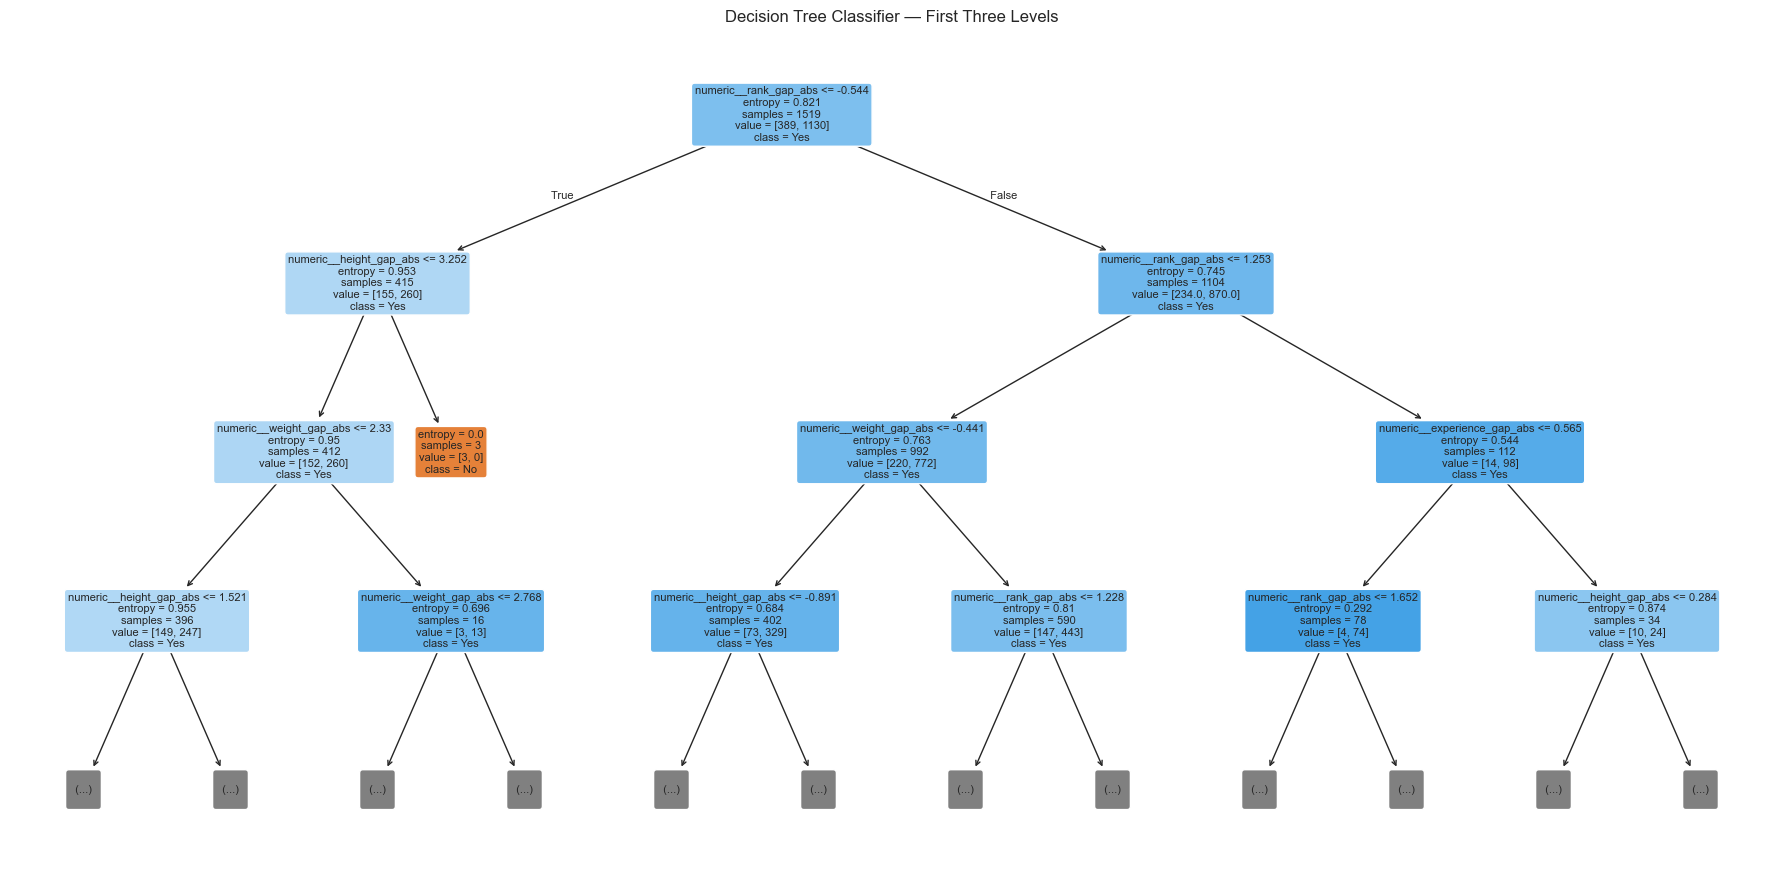

In [16]:
tree_preprocess = tree_best.named_steps["preprocess"]
tree_estimator = tree_best.named_steps["model"]

tree_feature_names = tree_preprocess.get_feature_names_out()

plt.figure(figsize=(18, 9))
plot_tree(
    tree_estimator,
    feature_names=tree_feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Classifier — First Three Levels")
plt.tight_layout()
plt.show()


**Tree interpretation.** The upper levels of the fitted tree show the features and thresholds used for the earliest decisions. These splits describe the model's decision structure; they should not be interpreted as causal rules about match outcomes.

## 5. Support Vector Machine (SVC)

SVM looks for a decision boundary with a large margin between the classes. The `C` parameter controls the trade-off between a wider margin and classification errors. With an RBF kernel, the model can represent non-linear boundaries. Scaling is important because the boundary depends on distances.

In [ ]:
svc_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", SVC(probability=True, random_state=RANDOM_STATE))
])

svc_grid = GridSearchCV(
    svc_model,
    {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

svc_grid.fit(X_train, y_train)
svc_best = svc_grid.best_estimator_

svc_pred = svc_best.predict(X_test)
svc_prob = svc_best.predict_proba(X_test)[:, 1]

svc_metrics = {
    "Model": "Support Vector Machine",
    "Accuracy": accuracy_score(y_test, svc_pred),
    "Precision_weighted": precision_score(y_test, svc_pred, average="weighted", zero_division=0),
    "Recall_weighted": recall_score(y_test, svc_pred, average="weighted", zero_division=0),
    "F1_weighted": f1_score(y_test, svc_pred, average="weighted", zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, svc_prob)
}

classification_results.append(svc_metrics)
classification_predictions["Support Vector Machine"] = svc_pred
classification_probabilities["Support Vector Machine"] = svc_prob
classification_models["Support Vector Machine"] = svc_best

print("Best parameters:", svc_grid.best_params_)
display(pd.DataFrame([svc_metrics]).round(4))


## Section D — Model Comparison

This table keeps all five Part-A algorithms together so the comparison is based on the same test split and the same metrics.

In [ ]:
classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values("F1_weighted", ascending=False)
    .reset_index(drop=True)
)

# Display the comparison table rounded to 4 decimal places.
display(classification_results_df.round(4))


### Separate classification model-comparison visualisation

In [ ]:
comparison_plot = classification_results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy", "Precision_weighted",
        "Recall_weighted", "F1_weighted", "ROC_AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=comparison_plot,
    x="Score",
    y="Model",
    hue="Metric"
)
plt.title("Classification Part A — Algorithm Comparison")
plt.xlabel("Score")
plt.ylabel("")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


**Model comparison.** The five classifiers are evaluated on the same held-out test set using the same metrics. This makes differences in performance attributable to the modelling approaches and their fitted parameters rather than to different test samples.

### Confusion matrices

The Review 1 rubric specifically asks for a confusion matrix for each Part-A classifier.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for ax, (name, pred) in zip(axes, classification_predictions.items()):
    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Confusion-matrix interpretation.** Each matrix separates correct predictions from false positives and false negatives. This gives class-level information that is not visible from accuracy alone.

### ROC curves for the five classifiers

ROC curves provide a visual view of how the classifiers separate the two classes at different probability thresholds.


In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))
for name, probabilities in classification_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_value = roc_auc_score(y_test, probabilities)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("ROC Curves — Classification Part A")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


**ROC interpretation.** The ROC curves show the trade-off between true-positive and false-positive rates across probability thresholds. ROC-AUC summarises the model's ability to separate the two classes over those thresholds.

## Section E — 5-Fold Cross-Validation for the Two Best Models

The two models with the highest weighted F1 on the held-out test set are evaluated using stratified 5-fold cross-validation on the training data. This provides an additional estimate of performance stability across different training and validation folds.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Select the two models with the highest weighted F1 on the held-out test set.
top_two_models = classification_results_df.head(2)["Model"].tolist()

cv_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for model_name in top_two_models:
    model = classification_models[model_name]

    # cross_val_score clones the estimator and fits a fresh copy
    # inside each training fold.
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv_splitter,
        scoring="f1_weighted",
        n_jobs=-1
    )

    cv_rows.append({
        "Model": model_name,
        "CV F1 mean": scores.mean(),
        "CV F1 std": scores.std()
    })

classification_cv_df = pd.DataFrame(cv_rows)

display(classification_cv_df.round(4))


## Review 1 classification reference

### Algorithm differences

- **Logistic Regression:** linear decision boundary with interpretable probability coefficients.
- **KNN:** local, distance-based classification; scaling is important.
- **Gaussian Naive Bayes:** probability-based classification with a conditional-independence assumption.
- **Decision Tree:** hierarchical decision rules controlled by split criteria and tree complexity.
- **SVM:** maximum-margin classification with optional non-linear kernels.

### Metric differences

- **Accuracy:** proportion of all predictions that are correct.
- **Precision:** proportion of predicted positive cases that are actually positive.
- **Recall:** proportion of actual positive cases that are correctly detected.
- **Weighted F1:** harmonic combination of precision and recall, weighted by class support.
- **ROC-AUC:** measures class-separation ability across probability thresholds.
- **Confusion matrix:** reports correct and incorrect predictions for each class.
